In [6]:
!pip install mlflow -q

In [7]:
from google.colab import files

uploaded = files.upload()

Saving CSE_Employability_Skill_Gap_50000_Realistic.xlsx to CSE_Employability_Skill_Gap_50000_Realistic (1).xlsx


In [8]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [9]:
df = pd.read_excel(next(iter(uploaded)))

In [11]:
print(df.shape)

(50000, 101)


In [13]:
df["student_id"] = df["Student_ID"].astype(str)

In [14]:
df["gender_encoded"] = (
    df["Gender"]
    .str.lower()
    .map({
        "male": 0,
        "female": 1,
        "other": 2
    })
)

In [15]:
df["gender_encoded"] = df["gender_encoded"].astype("int64")

In [16]:
df["age"] = df["Age"].astype("float32")

df["cgpa"] = df["CGPA"].astype("float32")

df["attendance"] = (
    df["Attendance_Percentage"]
    .astype("float32")
)

df["internships"] = (
    df["Internship_Count"]
    .astype("int64")
)

df["projects"] = (
    df["Projects_Completed"]
    .astype("int64")
)

In [17]:
df["academic_score"] = (
    df["Internal_Marks"]
    + df["External_Marks"]
    + df["Assignment_Average"]
) / 3

In [18]:
df["project_score"] = (
    df["Mini_Project_Score"]
    + df["Major_Project_Score"]
    + df["Lab_Performance"]
) / 3

In [19]:
technical_skills = [
    "C_Programming",
    "C++_Programming",
    "Java",
    "Python",
    "JavaScript",
    "SQL",
    "HTML_CSS",
    "ReactJS",
    "NodeJS",
    "Programming_Logic",
    "Machine_Learning",
    "Data_Preprocessing",
    "Feature_Engineering",
    "Model_Evaluation"
]

df["technical_skill_score"] = (
    df[technical_skills]
    .mean(axis=1)
)

In [20]:
soft_skills = [
    "Communication",
    "Teamwork",
    "Leadership",
    "Problem_Solving",
    "Critical_Thinking",
    "Time_Management",
    "Adaptability",
    "Creativity",
    "Presentation_Skills",
    "English_Proficiency"
]

df["soft_skill_score"] = (
    df[soft_skills]
    .mean(axis=1)
)

In [21]:
df["industry_readiness_score"] = (
    df["Internship_Count"]
    + df["Projects_Completed"]
    + df["Open_Source_Contributions"]
    + df["Hackathons_Attended"]
    + df["Certifications"]
) / 5

In [22]:
df["skill_gap_level"] = df["Skill_Gap_Level"]

In [23]:
processed_columns = [
    "student_id",
    "gender_encoded",
    "age",
    "cgpa",
    "attendance",
    "academic_score",
    "project_score",
    "technical_skill_score",
    "soft_skill_score",
    "industry_readiness_score",
    "internships",
    "projects",
    "skill_gap_level"
]

print(df[processed_columns].head())

print("\nMissing values:")
print(df[processed_columns].isnull().sum())

print("\nTarget distribution:")
print(df["skill_gap_level"].value_counts())

  student_id  gender_encoded   age  cgpa  attendance  academic_score  \
0  CSE000001               1  24.0  9.78       100.0       71.333333   
1  CSE000002               1  20.0  5.99        91.0       80.333333   
2  CSE000003               1  23.0  6.82        95.0       58.000000   
3  CSE000004               2  19.0  8.93        77.0       86.000000   
4  CSE000005               0  23.0  9.25        70.0       62.000000   

   project_score  technical_skill_score  soft_skill_score  \
0      58.666667               7.928571               6.3   
1      89.666667               2.428571               1.5   
2      93.666667               2.214286               2.7   
3      69.666667               5.357143               5.5   
4      88.000000               6.928571               6.2   

   industry_readiness_score  internships  projects skill_gap_level  
0                       8.2            3         4          Medium  
1                       6.8            0         8            

In [24]:
features = [
    "gender_encoded",
    "age",
    "cgpa",
    "attendance",
    "academic_score",
    "project_score",
    "technical_skill_score",
    "soft_skill_score",
    "industry_readiness_score",
    "internships",
    "projects"
]

target = "skill_gap_level"

X = df[features]

y = df[target]

print(X.head())
print(y.head())

   gender_encoded   age  cgpa  attendance  academic_score  project_score  \
0               1  24.0  9.78       100.0       71.333333      58.666667   
1               1  20.0  5.99        91.0       80.333333      89.666667   
2               1  23.0  6.82        95.0       58.000000      93.666667   
3               2  19.0  8.93        77.0       86.000000      69.666667   
4               0  23.0  9.25        70.0       62.000000      88.000000   

   technical_skill_score  soft_skill_score  industry_readiness_score  \
0               7.928571               6.3                       8.2   
1               2.428571               1.5                       6.8   
2               2.214286               2.7                       5.6   
3               5.357143               5.5                       4.6   
4               6.928571               6.2                       4.0   

   internships  projects  
0            3         4  
1            0         8  
2            2         6  
3 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
numerical_features = [
    "gender_encoded",
    "age",
    "cgpa",
    "attendance",
    "academic_score",
    "project_score",
    "technical_skill_score",
    "soft_skill_score",
    "industry_readiness_score",
    "internships",
    "projects"
]

In [27]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "missing_values",
            SimpleImputer(strategy="median")
        ),
        (
            "scaling",
            StandardScaler()
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        )
    ]
)

In [30]:
import mlflow
import mlflow.sklearn

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [31]:
mlflow.set_experiment(
    "CSE Employability Skill Gap Prediction"
)

2026/08/24 06:20:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/24 06:20:52 INFO mlflow.store.db.utils: Updating database tables
2026/08/24 06:20:58 INFO mlflow.tracking.fluent: Experiment with name 'CSE Employability Skill Gap Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1787552458680, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787552458680, lifecycle_stage='active', name='CSE Employability Skill Gap Prediction', tags={}, trace_location=None, workspace='default'>

In [32]:
with mlflow.start_run(run_name="Logistic Regression"):

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    max_iter=1000
                )
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    predictions = model_pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_param(
        "C",
        1.0
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print(
        "Logistic Regression Accuracy:",
        accuracy
    )

2026/08/24 06:21:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Accuracy: 0.8131


In [34]:
import mlflow
import mlflow.sklearn

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [35]:
with mlflow.start_run(run_name="Decision Tree"):

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    predictions = model_pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    mlflow.log_param(
        "model",
        "DecisionTree"
    )

    mlflow.log_param(
        "max_depth",
        5
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print(
        "Decision Tree Accuracy:",
        accuracy
    )

2026/08/24 06:22:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree Accuracy: 0.8369


In [36]:
with mlflow.start_run(run_name="Random Forest"):

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    predictions = model_pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    mlflow.log_param(
        "model",
        "RandomForest"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "max_depth",
        5
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print(
        "Random Forest Accuracy:",
        accuracy
    )

2026/08/24 06:23:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Accuracy: 0.8346


In [37]:
models = {
    "LogisticRegression": LogisticRegression(
        C=1.0,
        max_iter=1000
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

In [38]:
for model_name, model in models.items():

    with mlflow.start_run(
        run_name=model_name
    ):

        pipeline = Pipeline(
            steps=[
                (
                    "preprocessing",
                    preprocessor
                ),
                (
                    "model",
                    model
                )
            ]
        )

        pipeline.fit(
            X_train,
            y_train
        )

        predictions = pipeline.predict(
            X_test
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        mlflow.log_param(
            "model",
            model_name
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print(
            model_name,
            "Accuracy:",
            accuracy
        )

2026/08/24 06:23:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression Accuracy: 0.8131


2026/08/24 06:23:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree Accuracy: 0.8369


2026/08/24 06:23:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.8346


In [39]:
mlflow.set_tracking_uri(
    "sqlite:////content/mlflow.db"
)

mlflow.set_experiment(
    "CSE Employability Skill Gap Prediction"
)

print(
    "Tracking URI:",
    mlflow.get_tracking_uri()
)

Tracking URI: sqlite:////content/mlflow.db


In [40]:
for model_name, model in models.items():

    with mlflow.start_run(
        run_name=model_name
    ):

        pipeline = Pipeline(
            steps=[
                (
                    "preprocessing",
                    preprocessor
                ),
                (
                    "model",
                    model
                )
            ]
        )

        pipeline.fit(
            X_train,
            y_train
        )

        predictions = pipeline.predict(
            X_test
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        # Model name
        mlflow.log_param(
            "model",
            model_name
        )

        # Log all model parameters
        mlflow.log_params(
            model.get_params()
        )

        # Log accuracy
        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        # Save model
        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print(
            model_name,
            "Accuracy:",
            accuracy
        )

2026/08/24 06:24:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression Accuracy: 0.8131


2026/08/24 06:24:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree Accuracy: 0.8369


2026/08/24 06:24:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.8346


In [41]:
experiment = mlflow.get_experiment_by_name(
    "CSE Employability Skill Gap Prediction"
)

print(experiment)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1787552458680, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787552458680, lifecycle_stage='active', name='CSE Employability Skill Gap Prediction', tags={}, trace_location=None, workspace='default'>


In [42]:
runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,params.class_weight,params.max_features,params.min_weight_fraction_leaf,...,params.fit_intercept,params.max_iter,params.intercept_scaling,params.tol,params.multi_class,params.l1_ratio,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type
0,f68134d7e66a4330832ad696a14b92b4,1,FINISHED,/content/mlruns/1/f68134d7e66a4330832ad696a14b...,2026-08-24 06:24:42.745000+00:00,2026-08-24 06:24:52.520000+00:00,0.8346,None,sqrt,0.0,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,RandomForest,NOTEBOOK
1,4fd25105beef4b9cb7bb475ad12b4cbe,1,FINISHED,/content/mlruns/1/4fd25105beef4b9cb7bb475ad12b...,2026-08-24 06:24:32.494000+00:00,2026-08-24 06:24:42.714000+00:00,0.8369,None,None,0.0,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,DecisionTree,NOTEBOOK
2,b8addeeb1f094caeabb4cade5ad96daa,1,FINISHED,/content/mlruns/1/b8addeeb1f094caeabb4cade5ad9...,2026-08-24 06:24:17.888000+00:00,2026-08-24 06:24:32.468000+00:00,0.8131,None,None,None,...,True,1000,1,0.0001,deprecated,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,LogisticRegression,NOTEBOOK
3,3dfb752ba17c40f4b21de917995cfc10,1,FINISHED,/content/mlruns/1/3dfb752ba17c40f4b21de917995c...,2026-08-24 06:23:52.609000+00:00,2026-08-24 06:24:00.730000+00:00,0.8346,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,RandomForest,NOTEBOOK
4,f98c19a087ce42b68cab7a20bd0c4aa0,1,FINISHED,/content/mlruns/1/f98c19a087ce42b68cab7a20bd0c...,2026-08-24 06:23:39.202000+00:00,2026-08-24 06:23:52.573000+00:00,0.8369,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,DecisionTree,NOTEBOOK
5,8da400b4c46045c488e06e60be4f0f69,1,FINISHED,/content/mlruns/1/8da400b4c46045c488e06e60be4f...,2026-08-24 06:23:30.947000+00:00,2026-08-24 06:23:39.180000+00:00,0.8131,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,LogisticRegression,NOTEBOOK
6,9d6510031dca4dbfab8d1ae9b355bda0,1,FINISHED,/content/mlruns/1/9d6510031dca4dbfab8d1ae9b355...,2026-08-24 06:23:03.517000+00:00,2026-08-24 06:23:21.838000+00:00,0.8346,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,Random Forest,NOTEBOOK
7,fa9f659f994b4fb2bfd43b01d596ac7f,1,FINISHED,/content/mlruns/1/fa9f659f994b4fb2bfd43b01d596...,2026-08-24 06:22:35.050000+00:00,2026-08-24 06:22:44.601000+00:00,0.8369,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,Decision Tree,NOTEBOOK
8,52237a757a6e446db6539490c6979948,1,FAILED,/content/mlruns/1/52237a757a6e446db6539490c697...,2026-08-24 06:21:55.448000+00:00,2026-08-24 06:21:55.476000+00:00,NaN,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,Decision Tree,NOTEBOOK
9,22a44fa919db413b954f8283705f7930,1,FINISHED,/content/mlruns/1/22a44fa919db413b954f8283705f...,2026-08-24 06:21:14.801000+00:00,2026-08-24 06:21:43.116000+00:00,0.8131,None,None,None,...,None,None,None,None,None,None,fileId=1MvEnRUBI5Zs5rVdUJvoSfPnXueT2wDRf,root,Logistic Regression,NOTEBOOK


In [43]:
comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy"
    ]
].sort_values(
    "metrics.accuracy",
    ascending=False
)

comparison

,tags.mlflow.runName,params.model,params.C,params.max_depth,params.n_estimators,metrics.accuracy
1,DecisionTree,DecisionTree,None,5,None,0.8369
7,Decision Tree,DecisionTree,None,5,None,0.8369
4,DecisionTree,DecisionTree,None,None,None,0.8369
0,RandomForest,RandomForest,None,5,100,0.8346
3,RandomForest,RandomForest,None,None,None,0.8346
6,Random Forest,RandomForest,None,5,100,0.8346
2,LogisticRegression,LogisticRegression,1.0,None,None,0.8131
5,LogisticRegression,LogisticRegression,None,None,None,0.8131
9,Logistic Regression,LogisticRegression,1.0,None,None,0.8131
8,Decision Tree,None,None,None,None,NaN


In [44]:
comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy"
    ]
].copy()

In [45]:
comparison.columns = [
    "Run Name",
    "Model",
    "C",
    "Max Depth",
    "No. of Trees",
    "Accuracy"
]

In [46]:
comparison["Accuracy"] = (
    comparison["Accuracy"] * 100
).round(2)

In [47]:
comparison = comparison.sort_values(
    "Accuracy",
    ascending=False
)

comparison

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy
1,DecisionTree,DecisionTree,None,5,None,83.69
7,Decision Tree,DecisionTree,None,5,None,83.69
4,DecisionTree,DecisionTree,None,None,None,83.69
0,RandomForest,RandomForest,None,5,100,83.46
3,RandomForest,RandomForest,None,None,None,83.46
6,Random Forest,RandomForest,None,5,100,83.46
2,LogisticRegression,LogisticRegression,1.0,None,None,81.31
5,LogisticRegression,LogisticRegression,None,None,None,81.31
9,Logistic Regression,LogisticRegression,1.0,None,None,81.31
8,Decision Tree,None,None,None,None,NaN


In [48]:
best_models = (
    comparison
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .drop_duplicates(
        subset=["Model"]
    )
    .reset_index(
        drop=True
    )
)

best_models

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy
0,DecisionTree,DecisionTree,None,5,None,83.69
1,RandomForest,RandomForest,None,5,100,83.46
2,LogisticRegression,LogisticRegression,1.0,None,None,81.31
3,Decision Tree,None,None,None,None,NaN


In [50]:
best_models = best_models.dropna(
    subset=["Model", "Accuracy"]
).copy()

best_models["Model"] = best_models["Model"].astype(str)

best_models["Accuracy"] = pd.to_numeric(
    best_models["Accuracy"],
    errors="coerce"
)

best_models = best_models.dropna(
    subset=["Accuracy"]
)

print(best_models)

             Run Name               Model     C Max Depth No. of Trees  \
0        DecisionTree        DecisionTree  None         5         None   
1        RandomForest        RandomForest  None         5          100   
2  LogisticRegression  LogisticRegression   1.0      None         None   

   Accuracy  
0     83.69  
1     83.46  
2     81.31  


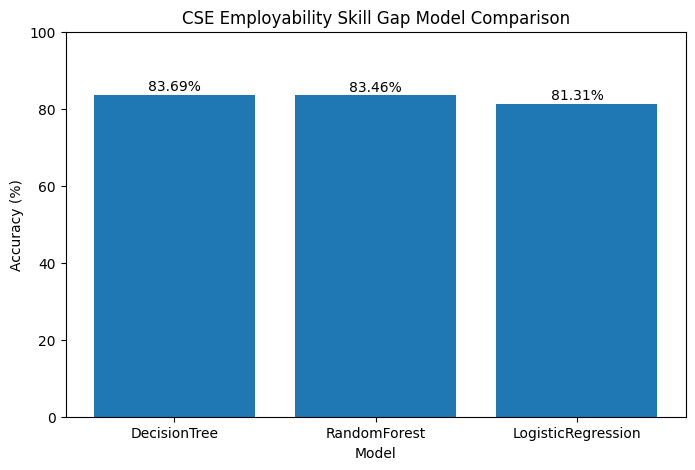

In [51]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    best_models["Model"],
    best_models["Accuracy"]
)

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.title(
    "CSE Employability Skill Gap Model Comparison"
)

plt.ylim(0, 100)

for i, value in enumerate(
    best_models["Accuracy"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [52]:
display(
    best_models[
        [
            "Model",
            "C",
            "Max Depth",
            "No. of Trees",
            "Accuracy"
        ]
    ].style
    .format(
        {
            "Accuracy": "{:.2f}%"
        }
    )
    .highlight_max(
        subset=["Accuracy"],
        axis=0
    )
)

,Model,C,Max Depth,No. of Trees,Accuracy
0,DecisionTree,None,5,None,83.69%
1,RandomForest,None,5,100,83.46%
2,LogisticRegression,1.0,None,None,81.31%
